## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
! git clone https://github.com/AngelikaBaloy/undergrad_ml_assignments/

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LassoCV, LinearRegression, lasso_path, Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


In [3]:
# 1. Load golub data
df = pd.read_csv('undergrad_ml_assignments/data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [4]:
# relabel ALLB & ALLT as 0; ALL as 1 (target variable)
df['cancer'].unique()

mapper = {'allB': 0,
          'allT': 0,
          'aml': 1}
df['y'] = df['cancer'].map(mapper) # making new col
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,y
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092,0
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577,0
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231,0
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116,0
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876,0


In [5]:
# 2. Use LR on all the genes
genes = df.drop(columns= ['y', 'cancer',
                          'Samples', 'BM.PB',
                          'Gender', 'Source',
                          'tissue.mf'])
y = df['y']

model = LinearRegression()
model.fit(genes, y)

y_hat = model.predict(genes)

# mean squared error
mse = mean_squared_error(y, y_hat)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 1.2522824482837894e-30


Text(0.5, 0, 'Residuals')

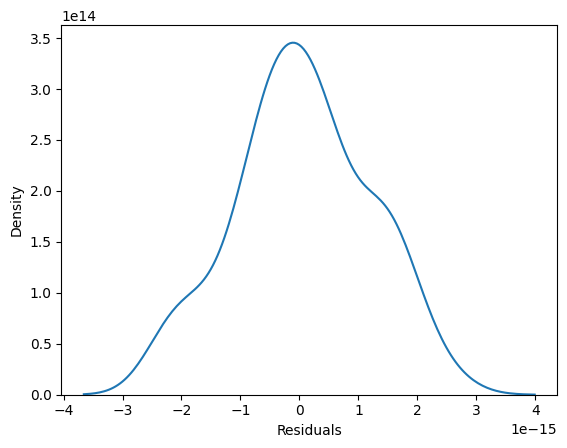

In [31]:
# kdeplot of residuals

sns.kdeplot(y - y_hat)
plt.xlabel("Residuals")

<Axes: xlabel='y'>

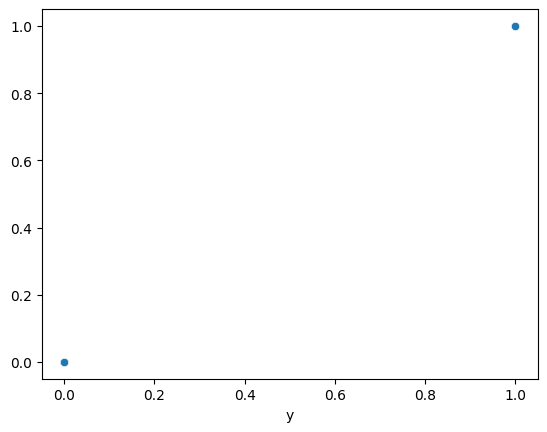

In [27]:
# scatter plot comparing predicted and actual outcomes

sns.scatterplot(x=y, y=y_hat)
# 0 and 1 are the only options so

In [35]:
# 3. Cross validation

model = LinearRegression()
model.fit(genes, y)

y_hat = model.predict(genes)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # going with 10 folds

mse_scorer = make_scorer(mean_squared_error)
scores = cross_val_score(
    model, genes, y,
    cv=kfold,
    scoring=mse_scorer
)

print("Fold scores", scores)
print("Mean score", np.mean(scores))
print("Median score", np.median(scores))
print("Std dev", np.std(scores))

# Results:
# It appears that the model is performing well, with low variance and little bias in predictions.
# Of course, some folds perform better than others. But predictions are relatively consistent
# and predictions are mostly correct.
# Since there are a lot of genes/predictor variables, there's ultimately a lot of noise.

Fold scores [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
Mean score 0.045876895088525556
Median score 0.03573571993995745
Std dev 0.027037144984588028


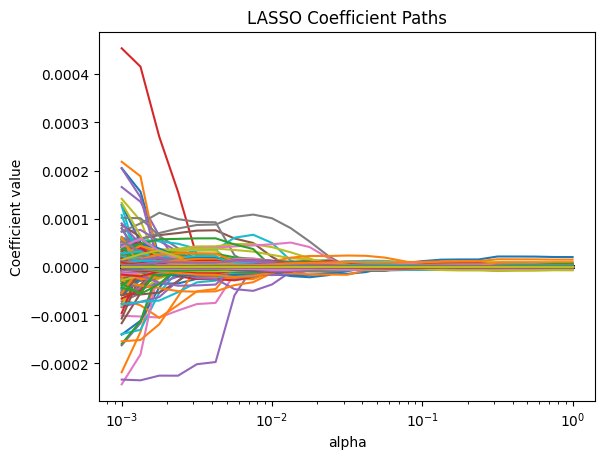

In [10]:
# 4. LASSO to select highly predictive genes
alpha_grid = np.logspace(-3, 0, 25)
coefs=[]
for alpha in alpha_grid:
  model= Lasso(alpha=alpha, max_iter=10_000)
  model = model.fit(genes, y)
  coefs.append(model.coef_)
coefs= np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
  plt.plot(alpha_grid, coefs[:, i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.357e-02, tolerance: 1.523e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.690e-03, tolerance: 1.302e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.699e-03, tolerance: 1.538e

Optimal cost hyperparameter: 10.0


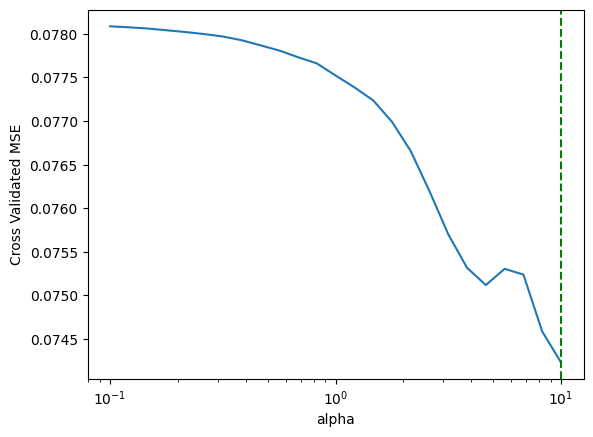

In [17]:
alpha_grid = np.logspace(-1, 1, 25)
model = LassoCV(cv=10,
                alphas=alpha_grid,
                random_state=100)
model = model.fit(genes, y)

index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]


sns.lineplot( x=model.alphas_, y= np.median(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

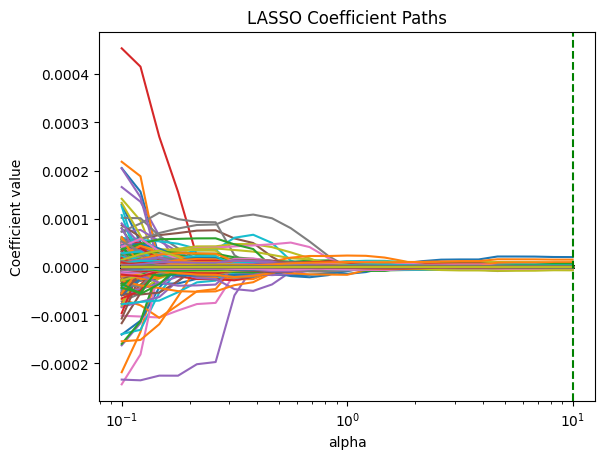

In [18]:
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

The linear regression model makes predictions based on the data it was trained on, so it performs well because it has seen the data before. The LASSO, though, cuts through the noise of the long list of genes and is able to narrow down itself to a select group of genes to base its predictions off of. Given new cases, the LASSO will provide better predictions.

7. Why do regularization methods lend themselves to scenarios like precision health?

There are a lot of attributes to consider in the context of precision health, so regularization is helpful when creating models. Doctors run a lot of tests and can collect a lot of data about a single patient, but using all of these data points for making predictions (eg. a diagnosis) is just going to create an over-fitted model. Selecting a few key attributes that help us make the most accurate predictions via regularization, is therefore a valuable strategy in precision health.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Health data is often complex, and measures may be impacted by extraneous variables. While the LASSO may lead us to consider a handful of variables to evaluate how to best treat patients, there's a larger story behind every variable and each person is living a different life. LASSOs won't always capture this nuance. As a result, applying LASSOs will not have perfect outcomes in this context, which can be risky in the case of giving choosing who receives interventions and who doesn't.